>##### 1. Import Libraries

In [1]:
# FasterRCNN with ResNet50 backbone on COCO dataset
# Training, Evaluation (Loss, Accuracy, R2, MAE, MSE), and Grad-CAM Visualization

# %pip install --quiet torch torchvision pycocotools matplotlib opencv-python scikit-learn tqdm grad-cam

# =============================================
# 1. Standard Library
# =============================================
import os
import math
import json
import contextlib
import io
from pathlib import Path
from typing import List, Tuple, Dict

# =============================================
# 2. Third-party Libraries
# =============================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =============================================
# 3. PyTorch & Torchvision
# =============================================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torchvision.ops import box_iou, nms
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.utils import draw_bounding_boxes

# =============================================
# 4. COCO API
# =============================================
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# =============================================
# 5. Grad-CAM
# =============================================
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# =============================================
# 6. Misc
# =============================================
from tqdm import tqdm  # (ถ้าใช้มากกว่า 1 ที่อาจเก็บไว้)


Note: you may need to restart the kernel to use updated packages.


>##### 2. Perform Dataset (COCO format)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "mps" if torch.backends.mps.is_available() else "cpu"  # for Mac M1
print("Device:", device)

def collate_fn(batch):
    return tuple(zip(*batch))

def coco_xywh_to_xyxy(boxes_xywh):
    boxes = torch.as_tensor(boxes_xywh, dtype=torch.float32)
    boxes_xyxy = boxes.clone()
    boxes_xyxy[..., 2] = boxes[..., 0] + boxes[..., 2]
    boxes_xyxy[..., 3] = boxes[..., 1] + boxes[..., 3]
    boxes_xyxy[..., 0] = boxes[..., 0]
    boxes_xyxy[..., 1] = boxes[..., 1]
    return boxes_xyxy

def draw_boxes(img_t, boxes, labels=None, color=(0,255,0), alpha=0.5):
    """img_t: CxHxW tensor [0,1] -> np.uint8 BGR"""
    img = (img_t.permute(1,2,0).cpu().numpy()*255).astype(np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    for i, b in enumerate(boxes):
        x1,y1,x2,y2 = [int(v) for v in b]
        cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
        if labels is not None:
            cv2.putText(img, str(int(labels[i])), (x1, max(0,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def greedy_match_iou(gt_boxes, pred_boxes, pred_scores, iou_thr=0.5):
    """Greedy match pred->gt by score desc. Returns list of (gt_idx, pred_idx)."""
    if len(gt_boxes)==0 or len(pred_boxes)==0:
        return []
    
    gt_boxes = gt_boxes.to(device)
    pred_boxes = pred_boxes.to(device)
    pred_scores = pred_scores.to(device)
    
    ious = box_iou(gt_boxes, pred_boxes)  # [G,P]
    matched = []
    used_gt = set()
    used_pred = set()
    order = torch.argsort(pred_scores, descending=True)
    for p in order.tolist():
        # pick best gt for this pred
        g = torch.argmax(ious[:, p]).item()
        if g in used_gt:
            continue
        if ious[g, p].item() >= iou_thr:
            matched.append((g, p))
            used_gt.add(g)
            used_pred.add(p)
    return matched


Device: cuda


In [3]:
class COCODetectionWrapper(Dataset):
    def __init__(self, img_dir, ann_file, transforms=None):
        
        super().__init__()
        with contextlib.redirect_stdout(io.StringIO()):
            self.coco = COCO(ann_file)
            
        self.img_dir = img_dir
        self.ids = list(self.coco.getImgIds())
        self.transforms = transforms if transforms is not None else T.ToTensor()

        # map catId -> contiguous [1..NUM_CLASSES] (bg=0)
        cat_ids = self.coco.getCatIds()
        self.catId_to_contig = {cat_id:i+1 for i,cat_id in enumerate(cat_ids)}
        self.contig_to_catId = {v:k for k,v in self.catId_to_contig.items()}
        self.num_classes = len(self.catId_to_contig)
        
        # เพิ่ม catId -> name mapping
        cats = self.coco.loadCats(cat_ids)
        self.catId_to_name = {c['id']: c['name'] for c in cats}
        self.classes = ['bg', 'objects', '1', '10', '2', '5']

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, index):
        img_id = self.ids[index]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        target_anns = self.coco.loadAnns(ann_ids)
        img_info = self.coco.loadImgs(img_id)[0]
        path = img_info["file_name"]
        img = Image.open(os.path.join(self.img_dir, path)).convert("RGB")
        img = self.transforms(img)

        boxes_xywh = []
        labels = []
        areas = []
        iscrowd = []

        for a in target_anns:
            if a.get("iscrowd", 0) == 1:  # keep but mark
                pass
            boxes_xywh.append(a["bbox"])
            # remap label to contiguous
            labels.append(self.catId_to_contig[a["category_id"]])
            areas.append(a.get("area", a["bbox"][2]*a["bbox"][3]))
            iscrowd.append(a.get("iscrowd", 0))

        if len(boxes_xywh) > 0:
            boxes = coco_xywh_to_xyxy(boxes_xywh)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            areas = torch.as_tensor(areas, dtype=torch.float32)
            iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)
        else:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id]),
            "area": areas,
            "iscrowd": iscrowd,
        }
        return img, target


>##### 3. Transforms & Dataloader

In [4]:
def save_prediction_results(img_int, pred_boxes, pred_labels, classes, num):
    save_img = draw_bounding_boxes(
        img_int, pred_boxes, [classes[i] for i in pred_labels], width=1
    ).permute(1, 2, 0)

    save_dir = "/home/smookka/project/results"
    os.makedirs(save_dir, exist_ok=True)
    plt.imsave(f"{save_dir}/result_{num}.png", save_img.numpy())

def filter_nms(pred_boxes, pred_labels, pred_scores, iou_threshold, score_threshold):
    # filter low score boxes
    mask = pred_scores > score_threshold
    pred_boxes = pred_boxes[mask]
    pred_labels = pred_labels[mask]
    pred_scores = pred_scores[mask]

    #  nms to remove overlapping boxes
    mask = nms(pred_boxes, pred_scores, iou_threshold)
    pred_boxes = pred_boxes[mask]
    pred_labels = pred_labels[mask]
    pred_scores = pred_scores[mask]
    return pred_boxes, pred_labels, pred_scores

In [5]:
transform = T.Compose([
    T.ToTensor(),
])

# DATASET_ROOT = "./dataset"  # โฟลเดอร์ที่มี train/ valid/ test/
DATASET_ROOT = "/home/smookka/project/dataset"  # โฟลเดอร์ที่มี train/ valid/ test/

TRAIN_IMG_DIR = f"{DATASET_ROOT}/train"
TRAIN_ANN = f"{DATASET_ROOT}/train/_annotations.coco.json"

VAL_IMG_DIR = f"{DATASET_ROOT}/valid"
VAL_ANN = f"{DATASET_ROOT}/valid/_annotations.coco.json"

TEST_IMG_DIR = f"{DATASET_ROOT}/test"
TEST_ANN = f"{DATASET_ROOT}/test/_annotations.coco.json"

NUM_CLASSES = 5 # +1 object classes (without background)

train_dataset = COCODetectionWrapper(TRAIN_IMG_DIR, TRAIN_ANN, transforms=transform)
val_dataset   = COCODetectionWrapper(VAL_IMG_DIR, VAL_ANN, transforms=transform)
test_dataset  = COCODetectionWrapper(TEST_IMG_DIR, TEST_ANN, transforms=transform)
print("Train/Validate/Test sizes:", len(train_dataset), len(val_dataset), len(test_dataset), "\n")

cat_ids = list(train_dataset.catId_to_name.keys())
cat_names = list(train_dataset.catId_to_name.values())
print("Category IDs in train:", cat_ids)
print("Category names:", cat_names)
print("Real classes:", len(cat_ids), "\n")

assert train_dataset.num_classes == NUM_CLASSES, \
    f"found {train_dataset.num_classes} classes from annotation but your NUM_CLASSES={NUM_CLASSES}"

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=8, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=8, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=8, collate_fn=collate_fn)

# --- Classes for visualization / drawing ---
classes = train_dataset.classes
classes = ['bg', 'objects', '1', '10', '2', '5']
print("Using classes for visualization:", classes)

Train/Validate/Test sizes: 3939 582 582 

Category IDs in train: [0, 1, 2, 3, 4]
Category names: ['objects', '1', '2', '5', '10']
Real classes: 5 

Using classes for visualization: ['bg', 'objects', '1', '10', '2', '5']


>##### 4. Model (Faster R-CNN, scratch)

In [6]:
# Function to pretty-print Faster R-CNN model architecture
def save_fasterrcnn_structure(model, save_path):
    with open(save_path, "w") as f:
        f.write("========= Faster-RCNN Model Architecture =========\n\n")

        # Backbone
        f.write("=== BACKBONE (Feature Extractor) ===\n")
        f.write(str(model.backbone))
        f.write("\n\n")

        # RPN (Region Proposal Network)
        f.write("=== RPN HEAD ===\n")
        f.write(str(model.rpn))
        f.write("\n\n")

        # ROI Heads (Classification + Box Regression)
        f.write("=== ROI HEADS ===\n")
        f.write(str(model.roi_heads))
        f.write("\n\n")

        f.write("========= END =========\n")


In [7]:
# Load pretrained backbone
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

# Change head to match with classes (bg=0 + NUM_CLASSES)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES + 1)

model.to(device)

# Save model architecture to text file
model_structure_path = "/home/smookka/project/fasterRCNN_model_structure.txt"
os.makedirs(os.path.dirname(model_structure_path), exist_ok=True)
save_fasterrcnn_structure(model, model_structure_path)

print(f"Pretty-formatted model structure saved to {model_structure_path}")

params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)


Pretty-formatted model structure saved to /home/smookka/project/fasterRCNN_model_structure.txt


>##### 5. Train One Epoch Function

In [8]:
def train_one_epoch(model, num_epochs, optimizer, data_loader, device, epoch, lr_scheduler=None):
    """
    Train one epoch with tqdm progress bar.
    Returns average epoch loss.
    """
    model.train()
    running_loss = 0.0

    # tqdm bar
    loop = tqdm(enumerate(data_loader), total=len(data_loader), desc=f"Epoch {epoch+1}/{num_epochs}", ncols=50)
    for i, (images, targets) in loop:
        images = [img.to(device) for img in images]
        targets = [{k: (v.to(device) if torch.is_tensor(v) else v) for k,v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += losses.item()
        avg_loss = running_loss / (i+1)

        # อัพเดต tqdm bar ให้โชว์ loss ปัจจุบัน
        loop.set_postfix({"batch_loss": f"{losses.item():.4f}", "avg_loss": f"{avg_loss:.4f}"})

    epoch_loss = running_loss / max(1, len(data_loader))
    if lr_scheduler is not None:
        lr_scheduler.step()
    return epoch_loss


>##### 6. Eval Model Function

In [9]:
def evaluate_model(model, data_loader, dataset_wrapper, device, iou_thr=0.5, return_loss=False):
    """
    Evaluate Faster-RCNN
    - mAP@0.5
    - Accuracy, MAE, MSE, R2
    - Optional: return average evaluation loss
    """
    model.eval()
    total_loss = 0.0
    num_batches = 0

    detections = []
    all_gt_labels, all_pred_labels = [], []

    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc="Evaluating", leave=False, ncols=50):
            images = [img.to(device) for img in images]
            targets = [{k: (v.to(device) if torch.is_tensor(v) else v) for k,v in t.items()} for t in targets]

            # ✅ Compute Loss in TRAIN mode even during eval
            if return_loss:
                model.train()  # temporarily switch to train mode to compute loss dict
                loss_dict = model(images, targets)
                batch_loss = sum(loss for loss in loss_dict.values())
                total_loss += batch_loss.item()
                num_batches += 1
                model.eval()  # switch back to eval for prediction

            # Detection
            outputs = model(images)
            for out, tgt in zip(outputs, targets):
                img_id = int(tgt["image_id"].item())
                if len(out["labels"]) == 0:
                    continue
                boxes = out["boxes"].cpu().numpy()
                scores = out["scores"].cpu().numpy()
                labels = out["labels"].cpu().numpy()
                contig_to_cat = dataset_wrapper.contig_to_catId
                for b, s, l in zip(boxes, scores, labels):
                    x1,y1,x2,y2 = b.tolist()
                    w = x2 - x1
                    h = y2 - y1
                    detections.append({
                        "image_id": img_id,
                        "category_id": int(contig_to_cat[int(l)]),
                        "bbox": [float(x1), float(y1), float(w), float(h)],
                        "score": float(s),
                    })

                # Pair metrics
                gt_boxes = tgt["boxes"]
                gt_labels = tgt["labels"]
                pred_boxes = out["boxes"].cpu()
                pred_labels = out["labels"].cpu()
                pred_scores = out["scores"].cpu()
                matches = greedy_match_iou(gt_boxes, pred_boxes, pred_scores, iou_thr=iou_thr)
                for g_idx, p_idx in matches:
                    all_gt_labels.append(int(gt_labels[g_idx].item()))
                    all_pred_labels.append(int(pred_labels[p_idx].item()))

    avg_loss = total_loss / max(1, num_batches) if return_loss else None

    # mAP
    tmp_det_path = "tmp_eval.json"
    with open(tmp_det_path, "w") as f:
        json.dump(detections, f)
        
    coco_gt = dataset_wrapper.coco
    with contextlib.redirect_stdout(io.StringIO()):  # ปิดการแสดงผล
        coco_dt = coco_gt.loadRes(tmp_det_path)
        coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
        coco_eval.params.iouThrs = np.array([0.5])
        coco_eval.evaluate()
        coco_eval.accumulate()
        coco_eval.summarize()
        
    map50 = float(coco_eval.stats[0])

    if len(all_gt_labels) == 0:
        acc = mse = mae = r2 = None
    else:
        y_true = np.array(all_gt_labels)
        y_pred = np.array(all_pred_labels)
        acc = (y_true==y_pred).mean()
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2  = r2_score(y_true, y_pred)

    metrics = {
        "mAP@0.5": map50,
        "accuracy": acc,
        "mse": mse,
        "mae": mae,
        "r2": r2,
    }

    if return_loss:
        metrics["eval_loss"] = avg_loss

    return metrics


>##### 7. Training Loop with tqdm

In [ ]:
num_epochs = 20
train_losses, val_losses = [], []
val_mae, val_mse, val_r2 = [], [], []
val_accuracies = [] 

# CHECKPOINT_DIR = "./fasterRCNN_checkpoints"
CHECKPOINT_DIR = "/home/smookka/project/fasterRCNN_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

best_val_loss = float("inf")
best_checkpoint_path = os.path.join(CHECKPOINT_DIR, "best.pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for epoch in range(num_epochs):
    # --- Train ---
    train_loss = train_one_epoch(
        model=model,
        num_epochs=num_epochs, 
        optimizer=optimizer, 
        data_loader=train_loader, 
        device=device, 
        epoch=epoch, 
        lr_scheduler=lr_scheduler
    )
    train_losses.append(train_loss)

    # --- Eval metrics ---
    metrics = evaluate_model(model, val_loader, val_dataset, device, return_loss=True)

    # เก็บค่าต่าง ๆ
    val_loss = metrics.get("eval_loss", None)
    val_losses.append(val_loss)
    val_accuracies.append(metrics.get("accuracy", 0.0))
    val_mae.append(metrics.get("mae", 0.0))
    val_mse.append(metrics.get("mse", 0.0))
    val_r2.append(metrics.get("r2", 0.0))

    print(f"[Epoch {epoch+1}] Eval metrics: {metrics}\n\n")
    
    # --- Save model checkpoint ---
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"model_epoch_{epoch+1}.pt")
    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "val_loss": val_loss,
    }, checkpoint_path)
    
     # --- Save best checkpoint ---
    if val_loss is not None and val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
        }, best_checkpoint_path)
        print(f"==> New best model saved at epoch {epoch+1} with val_loss={val_loss:.6f}\n\n")


Epoch 1/20: 100%|█| 247/247 [02:44<00:00,  1.50it/
Epoch 18/20: 100%|█| 247/247 [02:04<00:00,  1.98it


[Epoch 1] Eval metrics: {'mAP@0.5': 0.8654769579989124, 'accuracy': np.float64(0.8211818879508825), 'mse': 1.4980813507290867, 'mae': 0.511128165771297, 'r2': -0.17582424694631738, 'eval_loss': 0.09567889812830332}


==> New best model saved at epoch 1 with val_loss=0.095679




Epoch 2/20: 100%|█| 247/247 [02:11<00:00,  1.88it/


[Epoch 2] Eval metrics: {'mAP@0.5': 0.9515897257007913, 'accuracy': np.float64(0.9009976976208749), 'mse': 0.7467382962394474, 'mae': 0.2632386799693016, 'r2': 0.41389498346374654, 'eval_loss': 0.08778589400085243}


==> New best model saved at epoch 2 with val_loss=0.087786




Epoch 3/20: 100%|█| 247/247 [02:27<00:00,  1.68it/
Evaluating:   0%|          | 0/37 [00:00<?, ?it/s]

[Epoch 18] Eval metrics: {'mAP@0.5': 0.9942927911119379, 'accuracy': np.float64(0.9877206446661551), 'mse': 0.07290867229470453, 'mae': 0.0283960092095165, 'r2': 0.942774946998002, 'eval_loss': 0.041749058643708356}




Epoch 19/20: 100%|█| 247/247 [02:27<00:00,  1.67it


[Epoch 19] Eval metrics: {'mAP@0.5': 0.9942927911119379, 'accuracy': np.float64(0.9877206446661551), 'mse': 0.07290867229470453, 'mae': 0.0283960092095165, 'r2': 0.942774946998002, 'eval_loss': 0.04176309820566628}




Epoch 20/20:  58%|▌| 143/247 [01:41<01:12,  1.44it

>##### 7. Plot Loss Graph

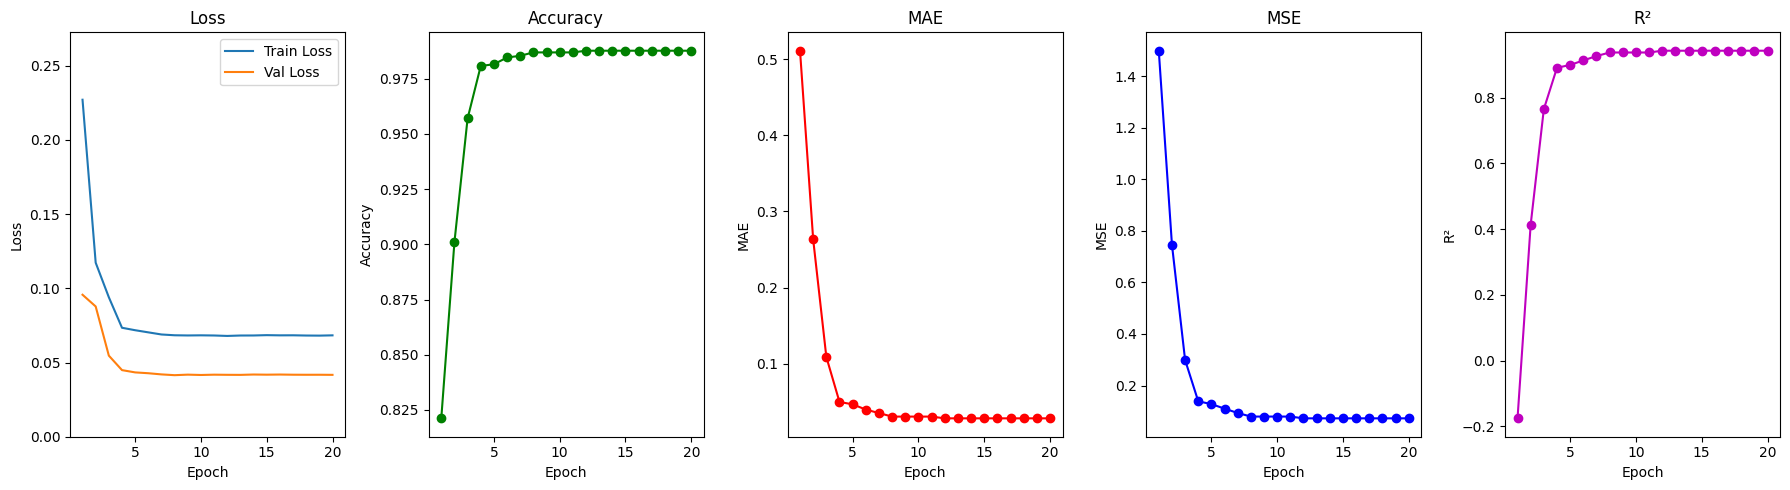

In [17]:
epochs = range(1, num_epochs+1)

plt.figure(figsize=(18,5))

plt.subplot(1,5,1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.ylim(0, max(max(train_losses), max(val_losses))*1.2)

plt.subplot(1,5,2)
plt.plot(epochs, val_accuracies, 'g-o')
plt.title("Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy")

plt.subplot(1,5,3)
plt.plot(epochs, val_mae, 'r-o')
plt.title("MAE"); plt.xlabel("Epoch"); plt.ylabel("MAE")

plt.subplot(1,5,4)
plt.plot(epochs, val_mse, 'b-o')
plt.title("MSE"); plt.xlabel("Epoch"); plt.ylabel("MSE")

plt.subplot(1,5,5)
plt.plot(epochs, val_r2, 'm-o')
plt.title("R²"); plt.xlabel("Epoch"); plt.ylabel("R²")

plt.tight_layout()
plt.show()

>##### 8. Evaluate Test set (MAE, MSE, R²)

In [13]:
# ----------------------
# Load the best checkpoint
CHECKPOINT_DIR = "/home/smookka/project/fasterRCNN_checkpoints"
best_checkpoint_path = os.path.join(CHECKPOINT_DIR, "best.pt")

checkpoint = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

# ----------------------
# Evaluate on test dataset
test_metrics = evaluate_model(model, test_loader, test_dataset, device, return_loss=True)

print("===> Test Metrics:")
for k,v in test_metrics.items():
    print(f"{k}: {v}")

epochs = range(1, num_epochs+1)

test_metrics_values = {
    "loss": test_metrics.get("eval_loss", 0),
    "accuracy": test_metrics.get("accuracy", 0),
    "mae": test_metrics.get("mae", 0),
    "mse": test_metrics.get("mse", 0),
    "r2": test_metrics.get("r2", 0)
}

===> Test Metrics:
mAP@0.5: 0.985647188698947
accuracy: 0.979182156133829
mse: 0.1546468401486989
mae: 0.0550185873605948
r2: 0.8820058997050148
eval_loss: 0.045561912545078506


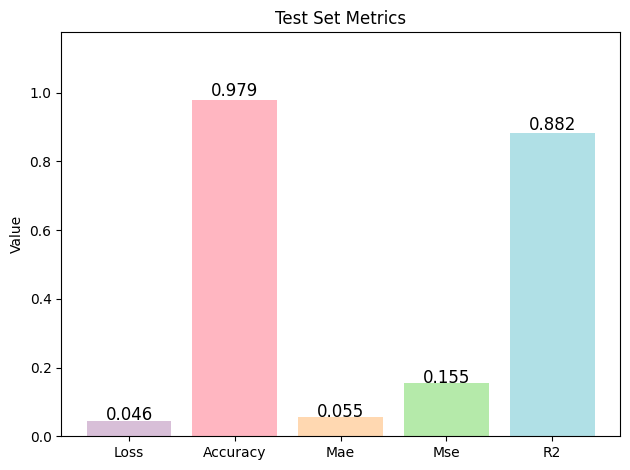

In [18]:
metrics_names = list(test_metrics_values.keys())
metrics_names = [name.title() for name in metrics_names]
metrics_vals  = list(test_metrics_values.values())

colors = ['#D8BFD8', '#FFB6C1', '#FFD8B1', '#B5EAAA', '#B0E0E6']  # loss, accuracy, mae, mse, r2
bars = plt.bar(metrics_names, metrics_vals, color=colors)

# เพิ่มค่าเหนือแท่ง
for bar, val in zip(bars, metrics_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01, f"{val:.3f}", ha='center', fontsize=12)

plt.title("Test Set Metrics")
plt.ylabel("Value")
plt.ylim(0, max(metrics_vals)*1.2)  # เพิ่ม margin บน
plt.tight_layout()
plt.show()


>##### 9. Grad-CAM Visualization

In [19]:
def visualize_gradcam_backbone(image_tensor, target_layer, device, title="Grad-CAM Backbone"):
    """
    Grad-CAM สำหรับ FasterRCNN backbone
    ใช้ feature map ของ backbone โดยตรง
    """
    rgb_img = image_tensor.permute(1,2,0).cpu().numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

    input_tensor = image_tensor.unsqueeze(0).to(device)

    # hook เก็บ feature map
    activations = []
    def forward_hook(module, inp, out):
        activations.append(out)
    handle = target_layer.register_forward_hook(forward_hook)

    with torch.no_grad():
        _ = model(input_tensor)

    handle.remove()

    feature_map = activations[0][0].cpu().numpy()  # [C,H_feat,W_feat]
    cam = feature_map.mean(axis=0)  # [H_feat, W_feat]

    # resize CAM ให้ตรงกับภาพ
    cam = cv2.resize(cam, (rgb_img.shape[1], rgb_img.shape[0]))
    cam = (cam - cam.min()) / (cam.max() - cam.min())

    visualization = show_cam_on_image(rgb_img, cam, use_rgb=True)
    return visualization


>##### 10. Visualize Gradcam

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Using classes:  ['bg', 'objects', '1', '10', '2', '5']


/tmp/ipykernel_3944044/3703896533.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_int = torch.tensor(img * 255, dtype=torch.uint8)


Correct prediction: [3] [3]
File name: one-back-00003_aug3_jpg.rf.e14071ec3d4fbb9087dd90346bfda330.jpg Image ID: 988
False prediction: [2] [5]


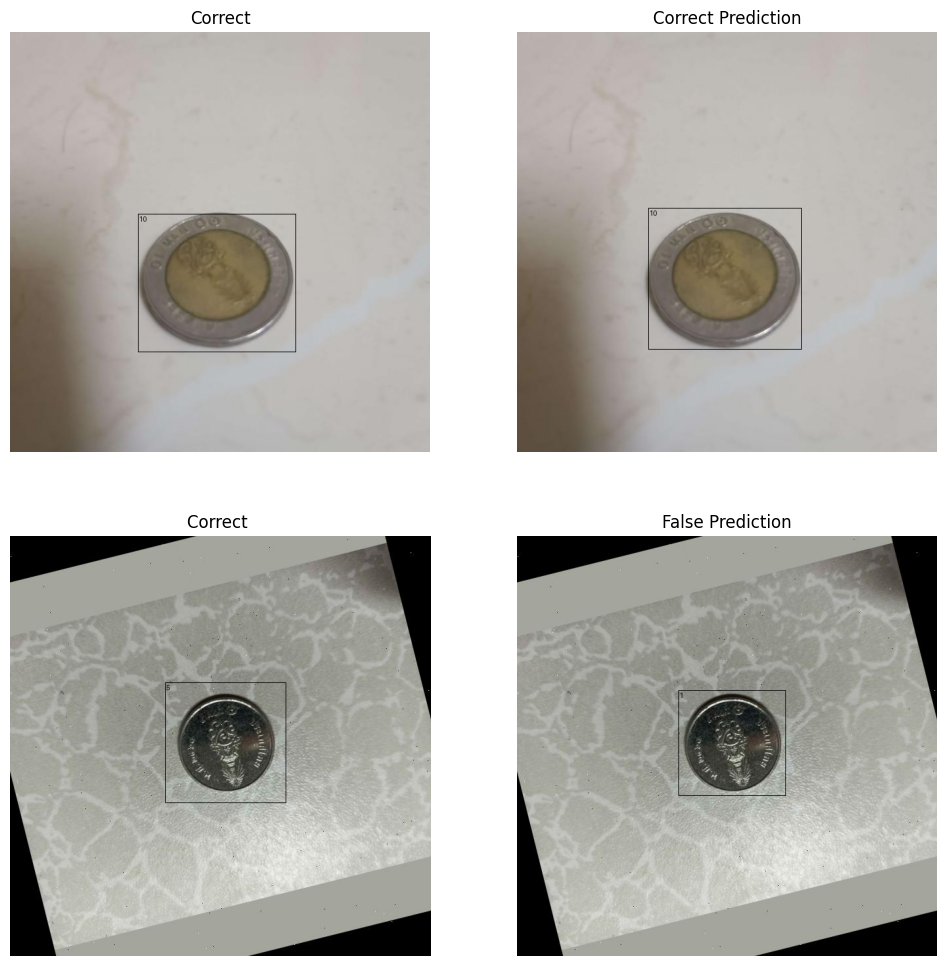

In [20]:

# for imgs, targets in val_loader:
#     img_tensor = imgs[0].to(device)
#     visualize_gradcam_backbone(img_tensor, target_layer, device)
#     break

correct = False
correct_img = None
false_pos = False
false_pos_img = None

# test = val_dataset[0]
# โหลด category names แบบอัตโนมัติจาก COCO
coco = COCO(TRAIN_ANN)
cat_ids = coco.getCatIds()
cats = coco.loadCats(cat_ids)

# --- Classes for visualization / drawing ---
classes = train_dataset.classes
print("Using classes: ", classes)

# classes = ['objects', 'bg', '1', '10', '2', '5']
model.eval()
target_layer = model.backbone.body.layer4[-1] # last block of layer4

fig, ax = plt.subplots(2, 2, figsize=(12, 12))
ax[0, 0].set_title("Correct")
ax[0, 0].axis("off")
ax[0, 1].set_title("Correct Prediction")
ax[0, 1].axis("off")
ax[1, 0].set_title("Correct ")
ax[1, 0].axis("off")
ax[1, 1].set_title("False Prediction")
ax[1, 1].axis("off")
i = 0

score_threshold = 0.6
iou_threshold = 0.5


for img, target in train_dataset:
    i += 1
    if len(target["labels"]) != 1:
        continue

    gt_labels = target["labels"].cpu().numpy()

    img_cuda = img.to(device)
    with torch.no_grad():
        output = model([img_cuda])[0]

    pred_boxes = output["boxes"].cpu()
    pred_labels = output["labels"].cpu().numpy()
    pred_scores = output["scores"].cpu()
    # pred_boxes, pred_labels, pred_scores = filter_nms(pred_boxes, pred_labels, pred_scores, iou_threshold, score_threshold)

    if len(pred_labels) != 1:
        continue

    img_int = torch.tensor(img * 255, dtype=torch.uint8)


    if pred_labels[0] == gt_labels[0] and not correct:
        correct = True
        correct_img = img

        print("Correct prediction:", pred_labels, gt_labels)
        ax[0, 0].imshow(draw_bounding_boxes(
            img_int, target["boxes"], [classes[i] for i in target["labels"]], width=1
        ).permute(1, 2, 0))
        ax[0, 1].imshow(draw_bounding_boxes(
            img_int, pred_boxes, [classes[i] for i in pred_labels], width=1
        ).permute(1, 2, 0))

    elif pred_labels[0] != gt_labels[0] and not false_pos:
        false_pos = True
        false_pos_img = img
        
        img_id = int(target["image_id"].item())
        img_info = train_dataset.coco.loadImgs(img_id)[0]
        file_name = img_info["file_name"]
        print("File name:", file_name, "Image ID:", img_id)

        print("False prediction:", pred_labels, gt_labels)
        ax[1, 0].imshow(draw_bounding_boxes(
            img_int, target["boxes"], [classes[i] for i in target["labels"]], width=1
        ).permute(1, 2, 0))
        ax[1, 1].imshow(draw_bounding_boxes(
            img_int, pred_boxes, [classes[i] for i in pred_labels], width=1
        ).permute(1, 2, 0))
        
    # if correct and false_pos:
    #     print("end loop")
    #     break
# {'boxes': tensor([[100.5663, 132.9429, 173.0736, 189.9566]], device='cuda:0',
#    grad_fn=<StackBackward0>), 'labels': tensor([3], device='cuda:0'), 'scores': tensor([0.9986], device='cuda:0', grad_fn=<IndexBackward0>)


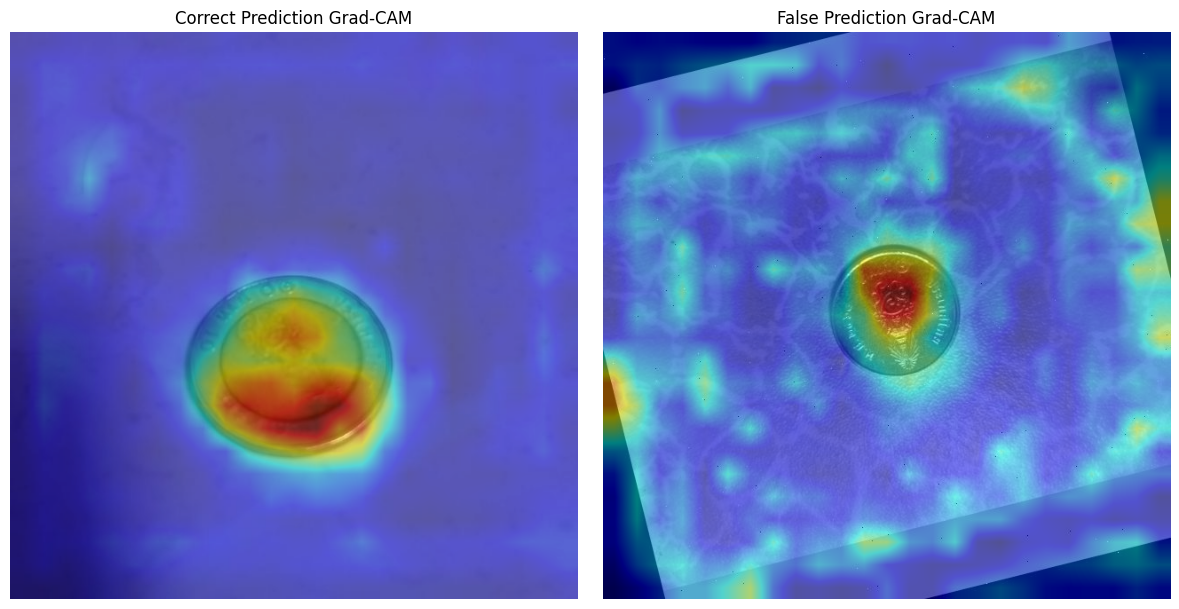

In [21]:
target_layer = model.backbone.body.layer4[-1]

# for imgs, targets in val_loader:
#     img_tensor = imgs[0].to(device)
#     visualize_gradcam_backbone(img_tensor, target_layer, device)
#     break

correct_cam = visualize_gradcam_backbone(correct_img, target_layer, device, title="Correct Prediction Grad-CAM")
false_cam = visualize_gradcam_backbone(false_pos_img, target_layer, device, title="False Prediction Grad-CAM")

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(correct_cam)
plt.title("Correct Prediction Grad-CAM")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(false_cam)
plt.title("False Prediction Grad-CAM")
plt.axis("off")

plt.tight_layout()
plt.show()